# Week 1 Assignment: Building a Neural Network for Iris Dataset Classification

## Task Description

Task is to build a simple neural network to classify the iris dataset. The iris dataset has four numerical features and a target variable with three classes (setosa, versicolor, virginica). The goal is to train a neural network to predict the class of iris based on the four features.

In [43]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.utils import to_categorical

# fetch dataset
iris_data = fetch_ucirepo(id=53)

# data (as pandas dataframes)
data = iris_data.data.original
data.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Preprocessing

Now we do some data preprocessing. First we will split the data to features and targets. Then we need to normalize the features so that they are on the same scale from 0 to 1. This is important for training the neural network effectively. We can use the `MinMaxScaler` from `sklearn.preprocessing` to achieve this. Then we will perform one-hot encoding on the target variable to convert the class labels into a format suitable for training the neural network.

In [44]:
# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

the whole data preprocessing steps are combined in the code below. We also shuffle the data using `np.random.shuffle` to ensure that the training process is not biased by the order of the data. At the end we print out a combined dataframe that includes the normalized features and the one-hot encoded targets for inspection. This allows us to verify that the preprocessing steps have been applied correctly before we proceed to model training.

In [45]:
# Splitting features and targets
X = data.drop(columns=['class'])
y = data['class']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode targets
y_encoded = pd.get_dummies(y, dtype=np.float32).to_numpy()
class_names = pd.get_dummies(y).columns.tolist()

# Shuffle with np.random.shuffle using a shared index
idx = np.arange(X_scaled.shape[0])
np.random.shuffle(idx)

X_shuf = X_scaled[idx]
y_shuf = y_encoded[idx]

# Combined dataframe for inspection (features + one-hot targets)
X_df = pd.DataFrame(X_shuf, columns=X.columns)
y_df = pd.DataFrame(y_shuf, columns=class_names)

combined_df = pd.concat([X_df, y_df], axis=1)

# Preview
combined_df.head(10)

,sepal length,sepal width,petal length,petal width,Iris-setosa,Iris-versicolor,Iris-virginica
0,0.500000,0.333333,0.627119,0.458333,0.0,1.0,0.0
1,0.388889,0.750000,0.118644,0.083333,1.0,0.0,0.0
2,0.944444,0.250000,1.000000,0.916667,0.0,0.0,1.0
3,0.472222,0.375000,0.593220,0.583333,0.0,1.0,0.0
4,0.694444,0.333333,0.644068,0.541667,0.0,1.0,0.0
5,0.305556,0.583333,0.084746,0.125000,1.0,0.0,0.0
6,0.361111,0.375000,0.440678,0.500000,0.0,1.0,0.0
7,0.722222,0.458333,0.694915,0.916667,0.0,0.0,1.0
8,0.527778,0.083333,0.593220,0.583333,0.0,1.0,0.0
9,0.416667,0.291667,0.491525,0.458333,0.0,1.0,0.0


## Training the Neural Network

Here we define a Sequential model with an input layer that matches the number of features (4), a hidden layer with 8 neurons and ReLU activation, and an output layer with 3 neurons (one for each class) and softmax activation. After trying out few different configurations, I found that 8 neurons in the hidden layer provided a good balance between model complexity and performance for this dataset.

In [46]:
# Declaring the model
model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

Then we compile the model using the Adam optimizer with a learning rate of 0.003, categorical crossentropy as the loss function (since this is a multi-class classification problem), and accuracy as the metric to evaluate during training. Adam optimezer means that the model will use an adaptive learning rate during training, which can help improve convergence. Categorical crossentropy is appropriate for multi-class classification problems where the target variable is one-hot encoded. Accuracy will allow us to monitor how well the model is performing in terms of correctly classifying the iris classes during training and validation.

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Now we train the model using the `fit` method. We pass in the shuffled features and targets, specify the number of epochs (150), batch size (32), and a validation split of 0.2 (20% of the data will be used for validation). The `fit` method will return a history object that contains the training and validation loss and accuracy for each epoch, which we can use to analyze the training process. I tried different numbers of epochs between 100 and 200, and found that 150 epochs provided a good balance between training time and model performance for this dataset.

In [48]:
# Training the model
history = model.fit(
    X_shuf, y_shuf,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.3250 - loss: 1.1043 - val_accuracy: 0.3667 - val_loss: 1.0592
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3250 - loss: 1.0793 - val_accuracy: 0.3667 - val_loss: 1.0372
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3250 - loss: 1.0579 - val_accuracy: 0.3667 - val_loss: 1.0185
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3250 - loss: 1.0395 - val_accuracy: 0.3333 - val_loss: 1.0036
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2750 - loss: 1.0235 - val_accuracy: 0.2000 - val_loss: 0.9895
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2083 - loss: 1.0080 - val_accuracy: 0.4000 - val_loss: 0.9756
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 0.9925 - val_accuracy: 0.4333 - val_loss: 0.9622
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4833 - loss: 0.9771 - val_accuracy: 0.4667 - val_loss:

After training the model, we can visualize the training and validation loss over epochs using a line plot. As long as the training and validation loss are decreasing and not diverging, it indicates that the model is learning effectively. If the validation loss starts to increase while the training loss continues to decrease, it may indicate overfitting, where the model is learning the training data too well and not generalizing to unseen data. By analyzing the loss curves, we can gain insights into the training process and make decisions about potential adjustments to the model architecture or training parameters if necessary.

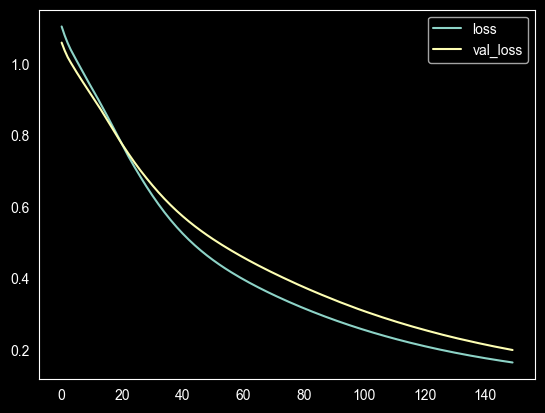

In [49]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss", "val_loss"])
plt.grid()
plt.show()

Finally, we evaluate the model on the entire dataset (since we don't have a separate test set) to get the final test accuracy. The `evaluate` method will return the loss and accuracy on the provided data. We print out the test accuracy to see how well our model performs on the iris dataset after training.

In [50]:
test_loss, test_acc = model.evaluate(X_scaled, y_encoded)
print(f'Test accuracy: {test_acc}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.1717 
Test accuracy: 0.9666666388511658


## Findings

After trying out different amount of neurons in the hidden layer, I found that 8 neurons gave the most consistent results in terms of training and validation loss. With 8 neurons, the model was able to learn effectively without overfitting, as indicated by the decreasing loss curves for both training and validation. The final test accuracy achieved with this configuration was over 95%. The code below shows the model summary, which includes the number of parameters in each layer and the total number of parameters in the model. This information can be useful for understanding the complexity of the model and how it may impact training and performance.

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203 (816.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 136 (548.00 B)